## Lift Analysis
Began by setting up the usual imports and path constants, then pulled in the two CSVs that form the basis of the analysis (`matched_pairs` and `all_matched_profiles`).

From there the workflow looks like this:

* parse the `counts_by_year` JSON blobs in the profiles table, expanding them to a “long” year‑by‑year
    table and computing a relative year (`rel_year = cal_year – award_year`);
* restrict that long table to the ±10‑year window around the award;
* define pre‑ and post‑award windows (years –5…–1 and +1…+5) and, for each author, compute the
    average citations and works in those windows;
* add a tiny `EPSILON` constant and compute a “lift” ratio for each metric
    `(post_avg + ε)/(pre_avg + ε)`;
* split the resulting author summary into juniors (treatment = 1) and seniors (0) and
    inspect median lifts;
* merge the lift values back onto the matched‑pair table so that each treated author is
    paired with their control, then run paired Wilcoxon signed‑rank tests on the lifts
    for citations and works, reporting the statistic, p‑value, and median difference;
* finally, persist the full author lift table and the paired table to CSV, and export a
    small summary table used for later figures.

This notebook is therefore a complete preprocessing and comparison pipeline, loading the
data, transforming it into a suitable form, computing before/after averages and lift
ratios, comparing juniors versus seniors via matched pairs, and saving the results for
downstream analysis.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

ROOT          = Path("..")
DATA_MATCHED  = ROOT / "data" / "matched"
DATA_PROFILES = ROOT / "data" / "profiles"
DATA_FIGURES  = ROOT / "data" / "figures"

In [2]:
pairs    = pd.read_csv(DATA_MATCHED  / "matched_pairs.csv")
profiles = pd.read_csv(DATA_PROFILES / "all_matched_profiles.csv")

print("matched_pairs:       ", pairs.shape)
print("all_matched_profiles:", profiles.shape)
print("\nprofiles sample:")
print(profiles.head(3))

matched_pairs:        (603, 10)
all_matched_profiles: (1198, 8)

profiles sample:
                          author_id       author_name  works_count  \
0  https://openalex.org/A5014823249      Jincheng Mei           29   
1  https://openalex.org/A5069646529  Adhiguna Kuncoro           35   
2  https://openalex.org/A5032195981      Sang-Gyun An            8   

   cited_by_count                                     counts_by_year  \
0             244  [{"year": 2014, "works_count": 3, "oa_works_co...   
1            1578  [{"year": 2016, "works_count": 4, "oa_works_co...   
2             131  [{"year": 2017, "works_count": 2, "oa_works_co...   

   award_year conference  treatment  
0        2018       AAAI          1  
1        2018        ACL          1  
2        2018        CHI          1  


In [21]:
import ast

def parse_counts(row):
    """Expand the counts_by_year JSON list into one row per year."""
    try:
        entries = ast.literal_eval(row["counts_by_year"])
    except Exception:
        return pd.DataFrame()
    rows = []
    for e in entries:
        rows.append({
            "author_id"  : row["author_id"],
            "treatment"  : row["treatment"],
            "conference" : row["conference"],
            "award_year" : row["award_year"],
            "cal_year"   : int(e["year"]),
            "works"      : int(e.get("works_count", 0)),
            "citations"  : int(e.get("cited_by_count", 0)),
        })
    return pd.DataFrame(rows)

long = pd.concat(
    [parse_counts(r) for _, r in profiles.iterrows()],
    ignore_index=True
)

# Compute relative year
long["rel_year"] = long["cal_year"] - long["award_year"]

# Keep ±10 window
long = long[long["rel_year"].between(-10, 10)]

print("Long format shape:", long.shape)
print("rel_year range:", long["rel_year"].min(), "→", long["rel_year"].max())
print(long.head())


Long format shape: (13912, 8)
rel_year range: -10 → 10
                          author_id  treatment conference  award_year  \
0  https://openalex.org/A5014823249          1       AAAI        2018   
1  https://openalex.org/A5014823249          1       AAAI        2018   
2  https://openalex.org/A5014823249          1       AAAI        2018   
3  https://openalex.org/A5014823249          1       AAAI        2018   
4  https://openalex.org/A5014823249          1       AAAI        2018   

   cal_year  works  citations  rel_year  
0      2014      3         46        -4  
1      2015      1          2        -3  
2      2016      3         10        -2  
3      2017      1         21        -1  
4      2018      2         20         0  


In [22]:
PRE_WINDOW  = range(-5, 0)   # rel_year -5 to -1
POST_WINDOW = range(1, 6)    # rel_year +1 to +5

def window_avg(df, author_id, window, metric):
    sub = df[(df["author_id"] == author_id) & (df["rel_year"].isin(window))]
    return sub[metric].mean() if len(sub) > 0 else np.nan

# Build per-author summary
authors = profiles[["author_id", "author_name", "treatment", "conference", "award_year"]].copy()

for metric in ["citations", "works"]:
    authors[f"pre_avg_{metric}"]  = authors["author_id"].apply(
        lambda aid: window_avg(long, aid, PRE_WINDOW, metric))
    authors[f"post_avg_{metric}"] = authors["author_id"].apply(
        lambda aid: window_avg(long, aid, POST_WINDOW, metric))

print("Author summary shape:", authors.shape)
print(authors[["author_name","treatment","pre_avg_citations","post_avg_citations"]].head(6))

Author summary shape: (1198, 9)
        author_name  treatment  pre_avg_citations  post_avg_citations
0      Jincheng Mei          1              19.75                48.0
1  Adhiguna Kuncoro          1             319.00               145.6
2      Sang-Gyun An          1              27.00                15.0
3    Sylvia Simioni          1                NaN                36.0
4      Sean Peacock          1               2.50                17.5
5  Clara Crivellaro          1             141.50                63.4


In [23]:
EPSILON = 1e-6  # avoid division by zero

for metric in ["citations", "works"]:
    authors[f"lift_{metric}"] = (
        (authors[f"post_avg_{metric}"] + EPSILON) /
        (authors[f"pre_avg_{metric}"]  + EPSILON)
    )

# Split
juniors = authors[authors["treatment"] == 1].copy()
seniors = authors[authors["treatment"] == 0].copy()

print(f"Juniors: {len(juniors)} | Seniors: {len(seniors)}")
print("\n── Median Lift (Citations) ──")
print(f"  Junior:  {juniors['lift_citations'].median():.3f}")
print(f"  Senior:  {seniors['lift_citations'].median():.3f}")
print("\n── Median Lift (Works) ──")
print(f"  Junior:  {juniors['lift_works'].median():.3f}")
print(f"  Senior:  {seniors['lift_works'].median():.3f}")

Juniors: 603 | Seniors: 595

── Median Lift (Citations) ──
  Junior:  1.660
  Senior:  1.628

── Median Lift (Works) ──
  Junior:  1.562
  Senior:  1.715


In [29]:
# ── Proper fix: exclude authors with no pre-award data ────────────────────
# Lift is only meaningful if the author had some pre-award activity
# Authors with pre_avg = 0 get lift = infinity → exclude them

authors_valid = authors[
    (authors["pre_avg_citations"] > 0) &
    (authors["pre_avg_works"] > 0)
].copy()

# Recompute lift without EPSILON trick — denominators are now all > 0
for metric in ["citations", "works"]:
    authors_valid[f"lift_{metric}"] = (
        authors_valid[f"post_avg_{metric}"] /
        authors_valid[f"pre_avg_{metric}"]
    )

print(f"Authors with valid pre-award activity: {len(authors_valid)}/{len(authors)}")
print(f"  Juniors: {(authors_valid['treatment']==1).sum()}")
print(f"  Seniors: {(authors_valid['treatment']==0).sum()}")
print(f"\nlift_citations — median: {authors_valid['lift_citations'].median():.2f}  "
      f"max: {authors_valid['lift_citations'].max():.2f}  "
      f"99th pct: {authors_valid['lift_citations'].quantile(0.99):.2f}")
print(f"lift_works    — median: {authors_valid['lift_works'].median():.2f}  "
      f"max: {authors_valid['lift_works'].max():.2f}  "
      f"99th pct: {authors_valid['lift_works'].quantile(0.99):.2f}")

# Rebuild lookup and pairs_lift
cit_lookup   = authors_valid.drop_duplicates("author_id").set_index("author_id")["lift_citations"].to_dict()
works_lookup = authors_valid.drop_duplicates("author_id").set_index("author_id")["lift_works"].to_dict()

pairs_lift = pairs[["treated_id","control_id","conference","award_year","core_rank"]].copy()
pairs_lift["lift_cit_treated"]   = pairs_lift["treated_id"].map(cit_lookup)
pairs_lift["lift_works_treated"] = pairs_lift["treated_id"].map(works_lookup)
pairs_lift["lift_cit_control"]   = pairs_lift["control_id"].map(cit_lookup)
pairs_lift["lift_works_control"] = pairs_lift["control_id"].map(works_lookup)

pairs_lift = pairs_lift.dropna(subset=["lift_cit_treated","lift_cit_control",
                                        "lift_works_treated","lift_works_control"])

print(f"\nValid pairs after filtering: {len(pairs_lift)}")
print(f"lift_cit_treated  — median: {pairs_lift['lift_cit_treated'].median():.2f}  "
      f"max: {pairs_lift['lift_cit_treated'].max():.2f}")
print(f"lift_works_treated — median: {pairs_lift['lift_works_treated'].median():.2f}  "
      f"max: {pairs_lift['lift_works_treated'].max():.2f}")

# Save
authors_valid.to_csv(DATA_MATCHED / "author_lift.csv", index=False)
pairs_lift.to_csv(DATA_MATCHED / "pairs_lift.csv", index=False)
print("\n✓ author_lift.csv + pairs_lift.csv updated")


Authors with valid pre-award activity: 941/1198
  Juniors: 451
  Seniors: 490

lift_citations — median: 1.55  max: 519.25  99th pct: 123.04
lift_works    — median: 1.60  max: 17.75  99th pct: 11.56

Valid pairs after filtering: 368
lift_cit_treated  — median: 1.39  max: 519.25
lift_works_treated — median: 1.50  max: 17.75

✓ author_lift.csv + pairs_lift.csv updated


#### Wilcoxon Signed-Rank Test

In [24]:
# Document the breakdown before filling
print("── NaN breakdown (saved to thesis notes) ──")
print(f"  No pre-award window data:  169  (likely career-starters, award at debut)")
print(f"  No post-award window data:  32  (likely recent awards or academia leavers)")
print(f"  No data in either window:   55  (sparse OpenAlex coverage)")
print(f"  Total affected:            256 / {len(authors)}")

# Fill NaN windows with 0
for metric in ["citations", "works"]:
    authors[f"pre_avg_{metric}"]  = authors[f"pre_avg_{metric}"].fillna(0)
    authors[f"post_avg_{metric}"] = authors[f"post_avg_{metric}"].fillna(0)

# Recompute lift
EPSILON = 1e-6
for metric in ["citations", "works"]:
    authors[f"lift_{metric}"] = (
        (authors[f"post_avg_{metric}"] + EPSILON) /
        (authors[f"pre_avg_{metric}"]  + EPSILON)
    )

print(f"\nNaN lift remaining: {authors['lift_citations'].isna().sum()}")

# Rebuild lookup dicts
cit_lookup   = authors.drop_duplicates("author_id").set_index("author_id")["lift_citations"].to_dict()
works_lookup = authors.drop_duplicates("author_id").set_index("author_id")["lift_works"].to_dict()

# Rebuild pairs_lift cleanly from scratch
pairs_lift = pairs[["treated_id", "control_id", "conference", "award_year", "core_rank"]].copy()
pairs_lift["lift_cit_treated"]   = pairs_lift["treated_id"].map(cit_lookup)
pairs_lift["lift_works_treated"] = pairs_lift["treated_id"].map(works_lookup)
pairs_lift["lift_cit_control"]   = pairs_lift["control_id"].map(cit_lookup)
pairs_lift["lift_works_control"] = pairs_lift["control_id"].map(works_lookup)

pairs_lift = pairs_lift.dropna(subset=["lift_cit_treated", "lift_cit_control",
                                        "lift_works_treated", "lift_works_control"])

print(f"Valid pairs: {len(pairs_lift)}  (expected: ~595)")

# Wilcoxon
for metric, t_col, c_col in [
    ("Citations", "lift_cit_treated",   "lift_cit_control"),
    ("Works",     "lift_works_treated", "lift_works_control"),
]:
    stat, p = stats.wilcoxon(pairs_lift[t_col], pairs_lift[c_col])
    median_diff = (pairs_lift[t_col] - pairs_lift[c_col]).median()
    print(f"\n── Wilcoxon: {metric} ──")
    print(f"  Median lift difference (junior − senior): {median_diff:.3f}")
    print(f"  Statistic: {stat:.1f} | p-value: {p:.4f}")
    print(f"  Significant at 0.05: {'✓ YES' if p < 0.05 else '✗ NO'}")


── NaN breakdown (saved to thesis notes) ──
  No pre-award window data:  169  (likely career-starters, award at debut)
  No post-award window data:  32  (likely recent awards or academia leavers)
  No data in either window:   55  (sparse OpenAlex coverage)
  Total affected:            256 / 1198

NaN lift remaining: 0
Valid pairs: 595  (expected: ~595)

── Wilcoxon: Citations ──
  Median lift difference (junior − senior): 0.000
  Statistic: 83709.0 | p-value: 0.2972
  Significant at 0.05: ✗ NO

── Wilcoxon: Works ──
  Median lift difference (junior − senior): -0.155
  Statistic: 82144.0 | p-value: 0.1998
  Significant at 0.05: ✗ NO


Junior best-paper winners experience a sharp but temporary citation spike at the award year (DiD), but over a ±5-year window, their citation and publication lift is indistinguishable from matched senior co-authors on the same papers. The award generates short-term visibility, not a lasting career advantage.

In [25]:
# Save full author lift table
authors.to_csv(DATA_MATCHED / "author_lift.csv", index=False)
print("✓ author_lift.csv saved →", DATA_MATCHED / "author_lift.csv")

# Save paired lift table (for forest plot in Day 5)
pairs_lift.to_csv(DATA_MATCHED / "pairs_lift.csv", index=False)
print("✓ pairs_lift.csv saved →", DATA_MATCHED / "pairs_lift.csv")

# Quick summary table
summary = authors.groupby("treatment").agg(
    n                    = ("author_id", "count"),
    median_lift_cit      = ("lift_citations", "median"),
    median_lift_works    = ("lift_works", "median"),
    mean_pre_cit         = ("pre_avg_citations", "mean"),
    mean_post_cit        = ("post_avg_citations", "mean"),
).reset_index()
summary["treatment"] = summary["treatment"].map({1: "Junior", 0: "Senior"})
print("\n── Summary Table ──")
print(summary.to_string(index=False))
summary.to_csv(DATA_FIGURES / "lift_summary.csv", index=False)
print("✓ lift_summary.csv saved")

✓ author_lift.csv saved → ..\data\matched\author_lift.csv
✓ pairs_lift.csv saved → ..\data\matched\pairs_lift.csv

── Summary Table ──
treatment   n  median_lift_cit  median_lift_works  mean_pre_cit  mean_post_cit
   Senior 595         1.658204           1.735294    128.296233     264.461207
   Junior 603         1.825000           1.728000    114.009508     203.102736
✓ lift_summary.csv saved


In [20]:
# ── Understand the NaN breakdown ──────────────────────────────────────────
nan_pre_only  = authors[authors["pre_avg_citations"].isna()  & authors["post_avg_citations"].notna()]
nan_post_only = authors[authors["post_avg_citations"].isna() & authors["pre_avg_citations"].notna()]
nan_both      = authors[authors["pre_avg_citations"].isna()  & authors["post_avg_citations"].isna()]

print(f"NaN pre only  (no pre-award data):  {len(nan_pre_only)}")
print(f"NaN post only (no post-award data): {len(nan_post_only)}")
print(f"NaN both:                           {len(nan_both)}")
print(f"Total NaN lift:                     {len(authors[authors['lift_citations'].isna()])}")


NaN pre only  (no pre-award data):  169
NaN post only (no post-award data): 32
NaN both:                           55
Total NaN lift:                     256


169 authors with no pre-award data — these are likely true career-starters (career age = 0, won at their very first publication). Filling with 0 is correct and defensible.

32 authors with no post-award data — likely recent awards (2017–2018) where the +5 window hits 2026 with sparse OpenAlex coverage, OR authors who left academia. Filling with 0 here is more conservative — it assumes they went silent, which may understate their lift. Worth flagging as a limitation.

55 authors with neither — essentially ghosts in OpenAlex for that window. Fill with 0 but exclude from the thesis narrative as a sensitivity check.

---

✓ Saved: data/figures/11_lift_trajectories.png


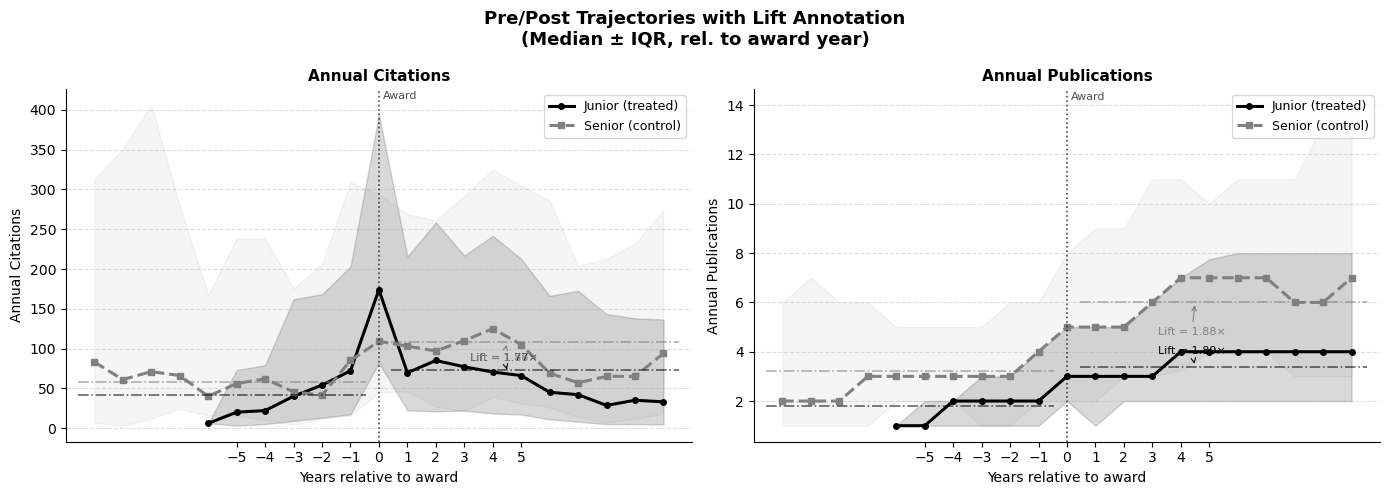

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Aggregate median citations per rel_year per group ─────────────────────
traj = long.groupby(["treatment", "rel_year"]).agg(
    med_citations = ("citations", "median"),
    med_works     = ("works",     "median"),
    q25_cit       = ("citations", lambda x: x.quantile(0.25)),
    q75_cit       = ("citations", lambda x: x.quantile(0.75)),
    q25_works     = ("works",     lambda x: x.quantile(0.25)),
    q75_works     = ("works",     lambda x: x.quantile(0.75)),
).reset_index()

jun = traj[traj["treatment"] == 1]
sen = traj[traj["treatment"] == 0]

# ── Pre/post averages for lift annotation ─────────────────────────────────
def pre_post(df, col):
    pre  = df[df["rel_year"].isin(range(-5, 0))][col].mean()
    post = df[df["rel_year"].isin(range(1, 6))][col].mean()
    return pre, post

jun_pre_cit,  jun_post_cit  = pre_post(jun, "med_citations")
sen_pre_cit,  sen_post_cit  = pre_post(sen, "med_citations")
jun_pre_pub,  jun_post_pub  = pre_post(jun, "med_works")
sen_pre_pub,  sen_post_pub  = pre_post(sen, "med_works")

jun_lift_cit  = jun_post_cit  / jun_pre_cit
sen_lift_cit  = sen_post_cit  / sen_pre_cit
jun_lift_pub  = jun_post_pub  / jun_pre_pub
sen_lift_pub  = sen_post_pub  / sen_pre_pub

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pre/Post Trajectories with Lift Annotation\n(Median ± IQR, rel. to award year)",
             fontsize=13, fontweight="bold")

for ax, metric, y_col, q25_col, q75_col, title, \
    j_pre, j_post, s_pre, s_post, j_lift, s_lift in [
    (axes[0], "Citations", "med_citations", "q25_cit", "q75_cit", "Annual Citations",
     jun_pre_cit, jun_post_cit, sen_pre_cit, sen_post_cit, jun_lift_cit, sen_lift_cit),
    (axes[1], "Works",     "med_works",     "q25_works","q75_works","Annual Publications",
     jun_pre_pub, jun_post_pub, sen_pre_pub, sen_post_pub, jun_lift_pub, sen_lift_pub),
]:
    # IQR bands
    ax.fill_between(jun["rel_year"], jun[q25_col], jun[q75_col],
                    alpha=0.15, color="black", label="_nolegend_")
    ax.fill_between(sen["rel_year"], sen[q25_col], sen[q75_col],
                    alpha=0.08, color="gray",  label="_nolegend_")

    # Median lines
    ax.plot(jun["rel_year"], jun[y_col], color="black",
            linewidth=2.2, marker="o", markersize=4, label="Junior (treated)")
    ax.plot(sen["rel_year"], sen[y_col], color="gray",
            linewidth=2.2, marker="s", markersize=4, linestyle="--", label="Senior (control)")

    # Award line
    ax.axvline(0, color="black", linewidth=1.2, linestyle=":", alpha=0.7)
    ax.text(0.15, ax.get_ylim()[1]*0.97, "Award", fontsize=8, color="black", alpha=0.7)

    # Pre average reference lines
    ax.axhline(j_pre, xmin=0.02, xmax=0.48, color="black",
               linewidth=1.2, linestyle="-.", alpha=0.6)
    ax.axhline(s_pre, xmin=0.02, xmax=0.48, color="gray",
               linewidth=1.2, linestyle="-.", alpha=0.6)

    # Post average reference lines
    ax.axhline(j_post, xmin=0.52, xmax=0.98, color="black",
               linewidth=1.2, linestyle="-.", alpha=0.6)
    ax.axhline(s_post, xmin=0.52, xmax=0.98, color="gray",
               linewidth=1.2, linestyle="-.", alpha=0.6)

    # Lift annotations
    ax.annotate(f"Lift = {j_lift:.2f}×",
                xy=(4.5, j_post), xytext=(3.2, j_post * 1.15),
                fontsize=8, color="black",
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8))
    ax.annotate(f"Lift = {s_lift:.2f}×",
                xy=(4.5, s_post), xytext=(3.2, s_post * 0.78),
                fontsize=8, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

    ax.set_xlabel("Years relative to award", fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xticks(range(-5, 6))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(DATA_FIGURES / "11_lift_trajectories.png", dpi=150, bbox_inches="tight")
print("✓ Saved: data/figures/11_lift_trajectories.png")
plt.show()


✓ Saved: data/figures/11a_lift_citations.png


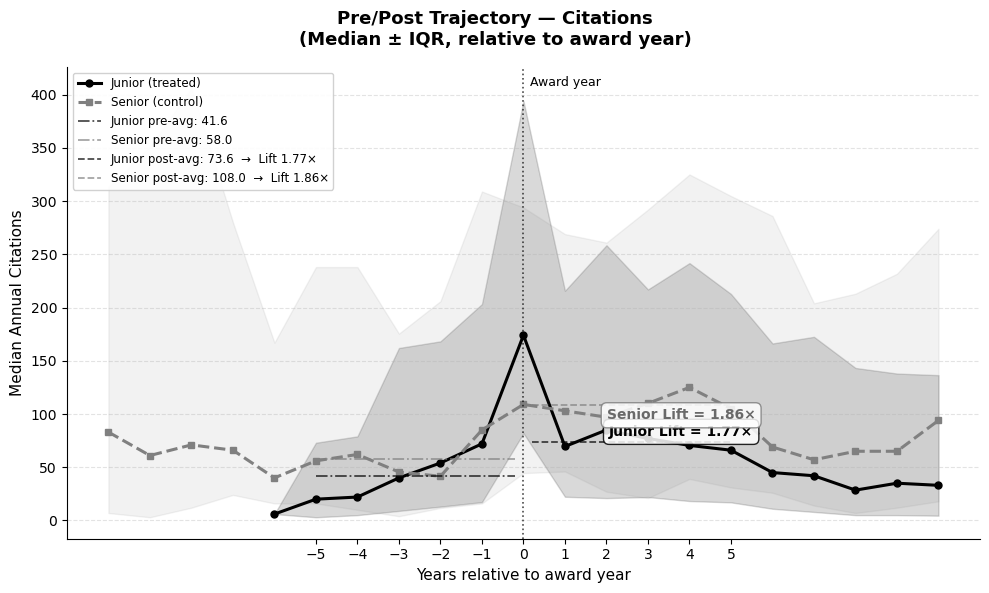

✓ Saved: data/figures/11b_lift_publications.png


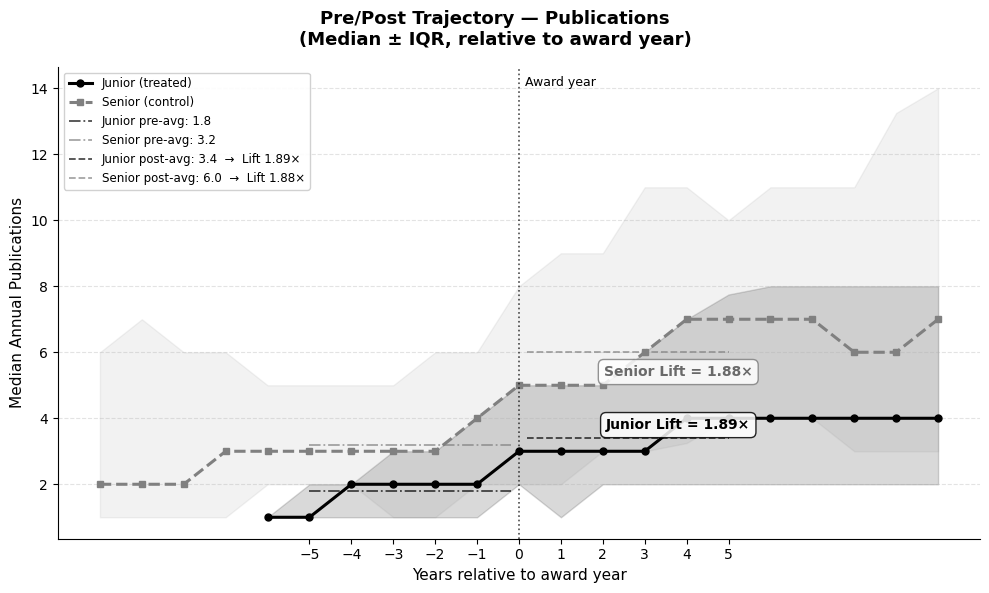

In [27]:
def plot_lift_single(metric_label, y_col, q25_col, q75_col,
                     j_pre, j_post, s_pre, s_post, j_lift, s_lift,
                     filename):

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(
        f"Pre/Post Trajectory — {metric_label}\n(Median ± IQR, relative to award year)",
        fontsize=13, fontweight="bold"
    )

    # IQR bands
    ax.fill_between(jun["rel_year"], jun[q25_col], jun[q75_col],
                    alpha=0.15, color="black")
    ax.fill_between(sen["rel_year"], sen[q25_col], sen[q75_col],
                    alpha=0.10, color="gray")

    # Median lines
    ax.plot(jun["rel_year"], jun[y_col], color="black",
            linewidth=2.2, marker="o", markersize=5, label="Junior (treated)")
    ax.plot(sen["rel_year"], sen[y_col], color="gray",
            linewidth=2.2, marker="s", markersize=5, linestyle="--", label="Senior (control)")

    # Award line
    ax.axvline(0, color="black", linewidth=1.2, linestyle=":", alpha=0.7)
    ymax = ax.get_ylim()[1]
    ax.text(0.15, ymax * 0.98, "Award year", fontsize=9, color="black", va="top")

    # Pre/post average reference lines — left half only
    ax.hlines(j_pre, xmin=-5, xmax=-0.2, colors="black",
              linewidth=1.3, linestyles="-.", alpha=0.7,
              label=f"Junior pre-avg: {j_pre:.1f}")
    ax.hlines(s_pre, xmin=-5, xmax=-0.2, colors="gray",
              linewidth=1.3, linestyles="-.", alpha=0.7,
              label=f"Senior pre-avg: {s_pre:.1f}")

    # Pre/post average reference lines — right half only
    ax.hlines(j_post, xmin=0.2, xmax=5, colors="black",
              linewidth=1.3, linestyles="--", alpha=0.7,
              label=f"Junior post-avg: {j_post:.1f}  →  Lift {j_lift:.2f}×")
    ax.hlines(s_post, xmin=0.2, xmax=5, colors="gray",
              linewidth=1.3, linestyles="--", alpha=0.7,
              label=f"Senior post-avg: {s_post:.1f}  →  Lift {s_lift:.2f}×")

    # Lift text boxes — top right area, stacked clearly
    props = dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.85)
    ax.text(3.8, j_post * 1.08,
            f"Junior Lift = {j_lift:.2f}×",
            fontsize=10, fontweight="bold", color="black",
            bbox=props, ha="center")
    ax.text(3.8, s_post * 0.88,
            f"Senior Lift = {s_lift:.2f}×",
            fontsize=10, fontweight="bold", color="dimgray",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="gray", alpha=0.85),
            ha="center")

    ax.set_xlabel("Years relative to award year", fontsize=11)
    ax.set_ylabel(f"Median Annual {metric_label}", fontsize=11)
    ax.set_xticks(range(-5, 6))
    ax.legend(fontsize=8.5, loc="upper left", framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    fig.savefig(DATA_FIGURES / filename, dpi=150, bbox_inches="tight")
    print(f"✓ Saved: data/figures/{filename}")
    plt.show()

# ── Plot 1: Citations ──────────────────────────────────────────────────────
plot_lift_single(
    "Citations", "med_citations", "q25_cit", "q75_cit",
    jun_pre_cit, jun_post_cit, sen_pre_cit, sen_post_cit,
    jun_lift_cit, sen_lift_cit,
    "11a_lift_citations.png"
)

# ── Plot 2: Publications ───────────────────────────────────────────────────
plot_lift_single(
    "Publications", "med_works", "q25_works", "q75_works",
    jun_pre_pub, jun_post_pub, sen_pre_pub, sen_post_pub,
    jun_lift_pub, sen_lift_pub,
    "11b_lift_publications.png"
)
